In [10]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage


In [11]:
from langgraph.graph import message
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [12]:
import os
from langchain_openai import ChatOpenAI

os.environ["OPENAI_API_KEY"] = "YOUR_API_KEY"

In [13]:
llm = ChatOpenAI()


def chat_node(state : ChatState):

    messages = state['messages']

    response = llm.invoke(messages)

    return {'messages': [response]}


In [14]:
graph = StateGraph( ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()




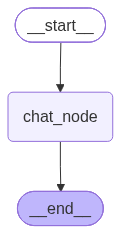

In [15]:
chatbot

In [24]:
import os
from langchain_openai import ChatOpenAI

os.environ["OPENAI_API_KEY"] = "YOUR_API_KEY"

In [2]:
initial_state= {
    'messages': [HumanMessage(content='what is the capital of india')]
}

chatbot.invoke(initial_state)['messages'][-1].content 

NameError: name 'HumanMessage' is not defined

In [3]:
from langchain_core.messages import HumanMessage

while True:
    user_message = input("Type here: ")

    if user_message.strip().lower() in ["exit", "quit", "bye"]:
        break

    response = chatbot.invoke({
        "messages": [HumanMessage(content=user_message)]
    })

    print("AI:", response["messages"][-1].content)

NameError: name 'chatbot' is not defined

In [ ]:
while True:

    user_message = input('Type here: ')

    if user_message.strip().lower() in ['exit', 'quit','bye']:
       break

    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]})

    print('AI:', response)

OpenAIAuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: YOUR_API_KEY. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}

In [6]:
thread_id = '1'

while True:

    user_message = input('Type here: ')

    print('user:' , user_message)

    if user_message.strip().lower() in ['exit', 'quit','bye']:
        break

    config = {'configurable': {'thread_id': thread_id}}

    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]},config=config)

    print('AI:', response['messages'][-1].content)

KeyboardInterrupt: Interrupted by user